# 02 — Método (BERT para séries temporais) e treinamento

## O método: reconstrução mascarada auto-supervisionada

A ideia do BERT (Devlin et al., 2019) transposta para séries temporais, como no
**TST** (Zerveas et al., 2021): não há rótulos — a própria série fornece a
supervisão (*self-supervised learning*). A tarefa-pretexto **é exatamente a
tarefa final**: esconder trechos da série e treinar o modelo para reconstruí-los.

```
valor + indicador de máscara ──Linear──► d_model
        + token [MASK] aprendível (posições escondidas)
        + codificação posicional senoidal
        ──► Encoder Transformer (masked multi-head SELF-ATTENTION, bidirecional)
        ──► Linear ──► valor reconstruído em cada passo de tempo
```

Pontos-chave da arquitetura ([src/modelo.py](src/modelo.py)):

- **Atenção bidirecional (não causal)** — para imputar o instante *t* o modelo
  atende ao passado **e** ao futuro, exatamente o que se quer em imputação
  (diferente de previsão, que só olha o passado);
- **Token `[MASK]` aprendível** + indicador binário de máscara na entrada — o
  modelo sabe *onde* deve imputar;
- **Codificação posicional senoidal** calculada dinamicamente — o modelo aceita
  janelas de qualquer comprimento, o que facilita transferir para outros datasets;
- **Perda: MSE apenas nas posições mascaradas** (como no BERT, a perda ignora as
  posições visíveis).

## Estratégias de mascaramento ([src/mascaramento.py](src/mascaramento.py))

Metade das janelas usa mascaramento **pontual** (falhas isoladas), metade usa
mascaramento **geométrico em blocos** com comprimento médio de 6 h (falhas
longas de sensor — o caso realista e difícil). Fração mascarada: 25 %.

## Reprodutibilidade

Sementes fixadas (`fixar_semente`), configuração completa salva no checkpoint,
early stopping pela perda de validação com máscaras **fixas por época**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, DESTAQUE_MASCARA
from src.modelo import BERTImputador
from src.treino import treinar, fixar_semente
from src.mascaramento import gerar_mascaras_lote, trechos_mascarados

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


In [2]:
# hiperparâmetros do experimento (salvos no checkpoint p/ reprodutibilidade)
CFG = {
    "semente": 42,
    "epocas": 40,
    "batch": 256,
    "lr": 1e-3,
    "paciencia": 6,          # early stopping
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
    "modelo": {"d_model": 64, "n_camadas": 3, "n_cabecas": 4, "d_ff": 256, "dropout": 0.1},
    "pasta_saida": "resultados",
}
CFG

{'semente': 42,
 'epocas': 40,
 'batch': 256,
 'lr': 0.001,
 'paciencia': 6,
 'mascara': {'razao': 0.25, 'prob_bloco': 0.5, 'lm': 6.0},
 'modelo': {'d_model': 64,
  'n_camadas': 3,
  'n_cabecas': 4,
  'd_ff': 256,
  'dropout': 0.1},
 'pasta_saida': 'resultados'}

## Visualizando a tarefa-pretexto

Uma janela de treino com as duas estratégias de máscara. As faixas cinzas são o
que o modelo **não vê** e precisa reconstruir a partir do contexto.

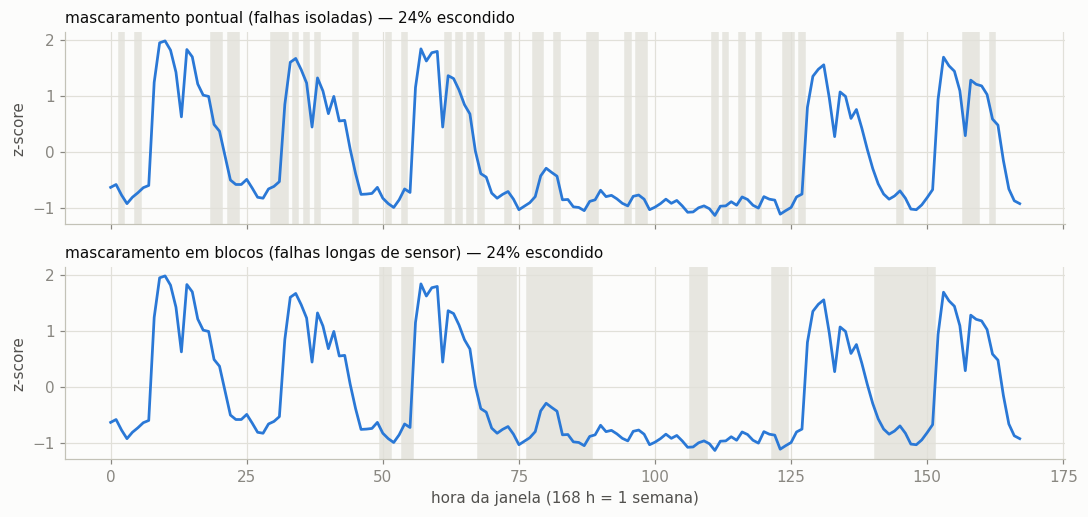

In [3]:
fixar_semente(CFG["semente"])
janela = arrays["treino"][3]
rng = np.random.default_rng(7)
m_pontual = gerar_mascaras_lote(1, len(janela), razao=0.25, prob_bloco=0.0, rng=rng)[0].numpy()
m_blocos = gerar_mascaras_lote(1, len(janela), razao=0.25, prob_bloco=1.0, rng=rng)[0].numpy()

fig, eixos = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True)
t = np.arange(len(janela))
for eixo, m, nome in [
    (eixos[0], m_pontual, "mascaramento pontual (falhas isoladas)"),
    (eixos[1], m_blocos, "mascaramento em blocos (falhas longas de sensor)"),
]:
    for ini, fim in trechos_mascarados(m):
        eixo.axvspan(ini - 0.5, fim - 0.5, color=DESTAQUE_MASCARA, zorder=0)
    eixo.plot(t, janela, color=PALETA["azul"])
    eixo.set_title(f"{nome} — {m.mean():.0%} escondido", loc="left", fontsize=10)
    eixo.set_ylabel("z-score")
eixos[-1].set_xlabel("hora da janela (168 h = 1 semana)")
fig.tight_layout()
plt.show()

## O modelo

In [4]:
fixar_semente(CFG["semente"])
modelo = BERTImputador(**CFG["modelo"])
n_par = sum(p.numel() for p in modelo.parameters())
print(f"parâmetros treináveis: {n_par:,}")
modelo

parâmetros treináveis: 150,401


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


BERTImputador(
  (proj_entrada): Linear(in_features=2, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norma_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (cabeca): Linear(in_features=64, out_features=1, bias=True)
)

## Treinamento

Perda = MSE nas posições mascaradas. AdamW + cosseno, gradiente clipado em 1.0,
early stopping pela validação (máscaras de validação idênticas em todas as
épocas, para a curva ser comparável). O melhor modelo é salvo em
`resultados/melhor_modelo.pt` junto com toda a configuração.

In [5]:
%%time
historico = treinar(modelo, ds_treino, ds_val, CFG, device, CFG["pasta_saida"])

época   1 | treino 0.2900 | val 0.1133  <- melhor


época   2 | treino 0.1176 | val 0.0913  <- melhor


época   3 | treino 0.1020 | val 0.0810  <- melhor


época   4 | treino 0.0939 | val 0.0752  <- melhor


época   5 | treino 0.0885 | val 0.0732  <- melhor


...

época  36 | treino 0.0624 | val 0.0585


época  37 | treino 0.0637 | val 0.0583  <- melhor


época  38 | treino 0.0632 | val 0.0585


época  39 | treino 0.0626 | val 0.0585


época  40 | treino 0.0635 | val 0.0583  <- melhor
CPU times: total: 15min 28s
Wall time: 14min 53s


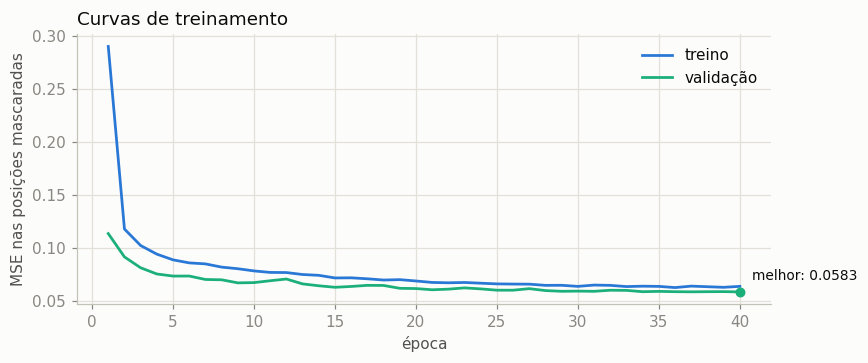

,epoca,perda_treino,perda_val
35,36,0.062351,0.058472
36,37,0.063727,0.058346
37,38,0.063160,0.058467
38,39,0.062594,0.058542
39,40,0.063503,0.058251


In [6]:
hist = pd.DataFrame(historico)

fig, eixo = plt.subplots(figsize=(8, 3.4))
eixo.plot(hist["epoca"], hist["perda_treino"], label="treino", color=PALETA["azul"])
eixo.plot(hist["epoca"], hist["perda_val"], label="validação", color=PALETA["verde_agua"])
melhor = hist.loc[hist["perda_val"].idxmin()]
eixo.scatter([melhor["epoca"]], [melhor["perda_val"]], color=PALETA["verde_agua"], zorder=3, s=30)
eixo.annotate(f"melhor: {melhor['perda_val']:.4f}",
              (melhor["epoca"], melhor["perda_val"]),
              textcoords="offset points", xytext=(8, 8), fontsize=9)
eixo.set_xlabel("época")
eixo.set_ylabel("MSE nas posições mascaradas")
eixo.set_title("Curvas de treinamento", loc="left")
eixo.legend()
fig.tight_layout()
plt.show()

hist.tail()

---
**Artefatos gerados** em `resultados/`: `melhor_modelo.pt` (pesos + hiperparâmetros
+ configuração) e `historico.json` (curvas de perda).

**Próximo passo:** [03_avaliacao.ipynb](03_avaliacao.ipynb) — avaliação no teste
contra baselines clássicos, em cenários controlados de dados faltantes.